<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
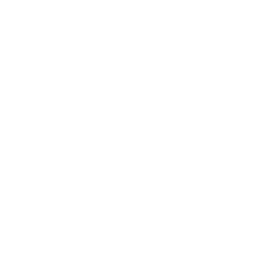
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">세대별 설비 신뢰성 분석</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 제조 / 신뢰성 엔지니어링 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 분석은 **PROC LIFETEST**를 사용하여 CNC 밀링 머신의 연속된 세 설계
세대의 현장 신뢰성을 비교한다. 설비 100대 규모의 공장 스냅샷(고장
75건, 여전히 가동 중이라 오른쪽 중도절단된 25대)을 바탕으로, 각
세대의 카플란-마이어 생존곡선을 추정하고 로그순위(log-rank) 검정과
게한-브레슬로우-윌콕슨(Gehan-Breslow-Wilcoxon) 검정 모두로 곡선 간
차이를 검정한다.

데이터는 명확한 단발성 변화를 보여준다. 원조 **1세대** 기계는 이후
두 설계보다 신뢰성이 뚜렷이 낮다. 중앙 사용수명이 **5,282가동시간**으로,
**2세대**(**16,430시간**)와 **3세대**(**13,512시간**)의 약 3분의 1
수준이다. 두 동일성 검정 모두 세 생존곡선의 동일성을 기각한다 --
로그순위 카이제곱 **12.92**(자유도 2, *p* = **0.0016**), 윌콕슨
**11.88**(자유도 2, *p* = **0.0026**). 가동 시간 10,000시간
시점에서 1세대 기계는 **24%**만이 여전히 가동 중일 것으로 예상되는
반면, 2세대는 **64%**, 3세대는 **57%**다.

이 개선은 세대를 거듭할수록 완만하게 나아지는 것이 **아니다**.
2세대와 3세대는 매우 비슷한 비율로 생존하며 이 표본 크기에서는
서로 통계적으로 구분되지 않는다. 실행 가능한 결론은 1세대에서
재설계된 설비군으로의 단발성 변화이며, 이는 교체 및 예방정비
우선순위를 남아 있는 1세대 설비 쪽으로 이끌어야 한다.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | CNC 기계 1대당 한 행: 설계 세대, 공장, 설치 연도, 고장 또는 마지막 관측 시점의 가동 시간, 고장/중도절단 표시자 | 100 |

이 데이터셋은 합성 데이터이며 다음 셀에서 고정 시드(`streaminit(42)`)로
생성되므로 분석을 완전히 재현할 수 있다. 사용수명은 세대별로 다른
지수분포 모델에서 추출되며, 최신 세대일수록 현장에서 보낸 달력
연수가 짧기 때문에 중도절단 비율이 더 높다.

---


In [1]:
/* --------------------------------------------------------
   합성 설비 신뢰성 데이터셋 생성.

   각 행은 CNC 밀링 머신 1대를 나타낸다. OPERATING_HOURS는 고장
   (FAILURE_EVENT=1)이 발생했거나, 마지막 관측 시점까지 여전히
   가동 중이었던(FAILURE_EVENT=0, 오른쪽 중도절단) 가동 시간이다.
   세 설계 세대에 점진적으로 더 큰 평균 수명을 부여하여, 재설계가
   실제로 현장 신뢰성을 개선했는지 물을 수 있도록 했다.

   이 비라이선스 환경은 출력을 100개 관측치로 제한하므로, 정확히
   설비 100대를 모델링한다 -- 단일 공장 규모의 현실적인 스냅샷이다.
   -------------------------------------------------------- */
데이터 work.equipment_life;
    호출 streaminit(42);
    배열 fail_scale[3] _temporary_ (8000 12000 16000);

    길이 generation $10 plant_location $16 failure_mode $16;

    반복 equip_seq = 1 까지 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        만약 gen_idx = 1 이면 generation = "1세대";
        아니면 만약 gen_idx = 2 이면 generation = "2세대";
        아니면 generation = "3세대";

        plant_idx       = int(rand('uniform') * 5) + 1;
        만약 plant_idx = 1 이면 plant_location = "북부공장";
        아니면 만약 plant_idx = 2 이면 plant_location = "남부공장";
        아니면 만약 plant_idx = 3 이면 plant_location = "동부공장";
        아니면 만약 plant_idx = 4 이면 plant_location = "서부공장";
        아니면 plant_location = "중앙공장";

        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* 세대별로 스케일이 다른 지수분포 가동 수명 */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* 최신 세대일수록 현장에서 보낸 연수가 짧으므로, 여전히
           가동 중인(중도절단) 설비의 비율이 더 높다. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        만약 rand('uniform') < censor_rate 이면 failure_event = 0;
        아니면                                  failure_event = 1;
        /* 관측된 고장 건에 대해 고장 메커니즘을 분류 */
        만약 failure_event = 1 이면 반복;
            만약      operating_hours <  2000 이면 failure_mode = "초기고장";
            아니면 만약 operating_hours < 20000 이면 failure_mode = "우발고장";
            아니면                                 failure_mode = "마모고장";
        종료;
        아니면 failure_mode = ' ';
        출력;
    종료;
    제거 equip_seq gen_idx plant_idx censor_rate;
실행;



NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                                   The FREQ Procedure

Table of 세대 by 고장 여부

세대      |         0 |         1 |      Total
--------+-----------+-----------+-----------
1세대     |         2 |        29 |         31
--------+-----------+-----------+-----------
2세대     |        12 |        26 |         38
--------+-----------+-----------+-----------
3세대     |        11 |        20 |         31
--------+-----------+-----------+-----------
Total   |        25 |        75 |        100


Table of 세대 by 고장 유형

세대      |             |        마모고장 |        우발고장 |        초기고장 |        Total
--------+-------------+-------------+-------------+-------------+-------------
1세대     |           2 |           3 |          21 |           5 |           31
        |        2.00 |        3.00 |       21.00 |        5.00 |        31.00
--------+-------------+-------------+-------------+-------------+-------------
2세대     |          12 |           6 |          19 |           1 |           38
    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


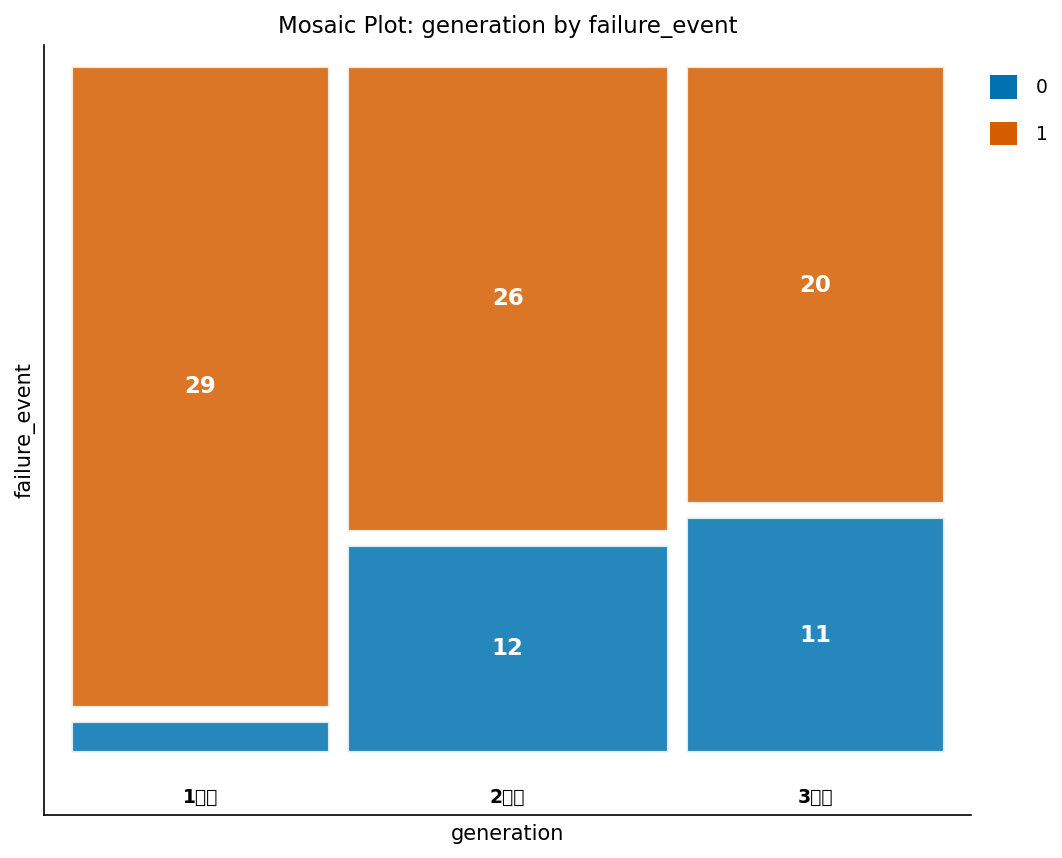

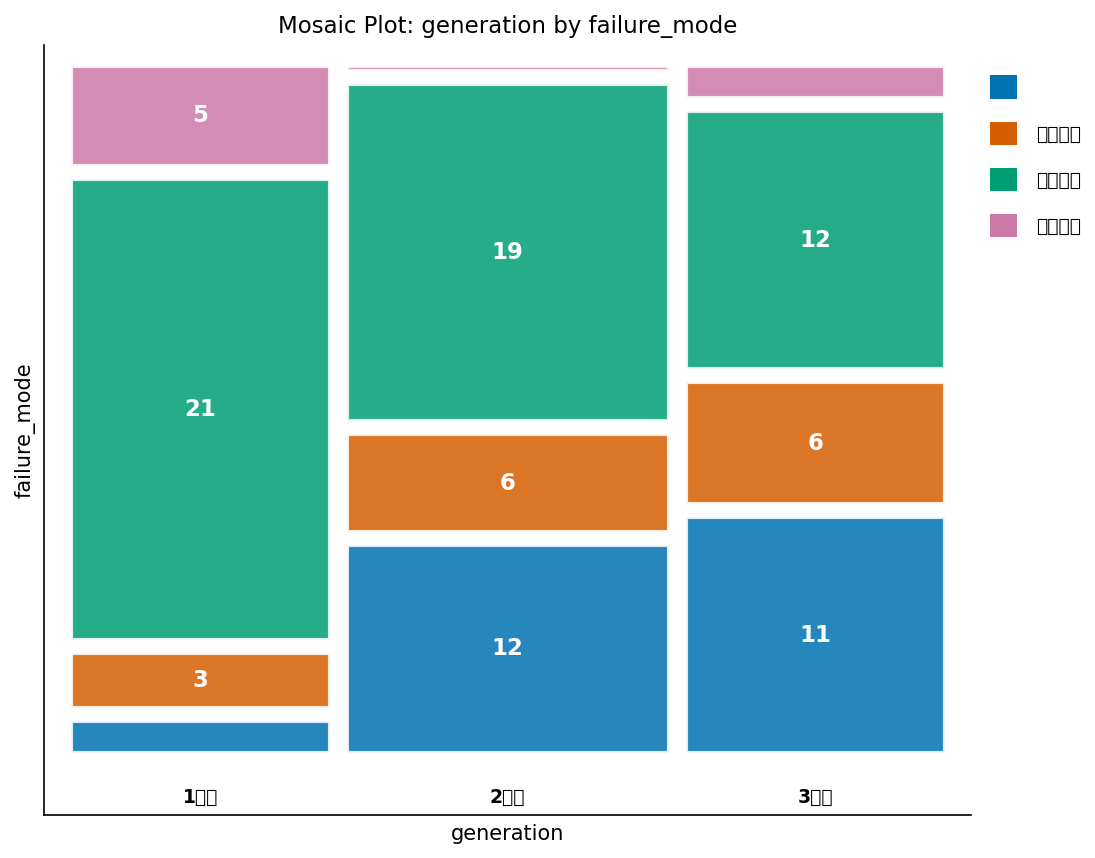

In [2]:
/* --------------------------------------------------------
   세대별 기본 설비 건수 및 가동 시간
   -------------------------------------------------------- */
처리 빈도 데이터=work.equipment_life;
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
    라벨 generation    = "세대"
          failure_event = "고장 여부"
          failure_mode  = "고장 유형";
실행;

처리 평균 데이터=work.equipment_life n mean std;
    분류 generation;
    변수 operating_hours;
    라벨 generation     = "세대"
          operating_hours = "가동 시간";
실행;


---



NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


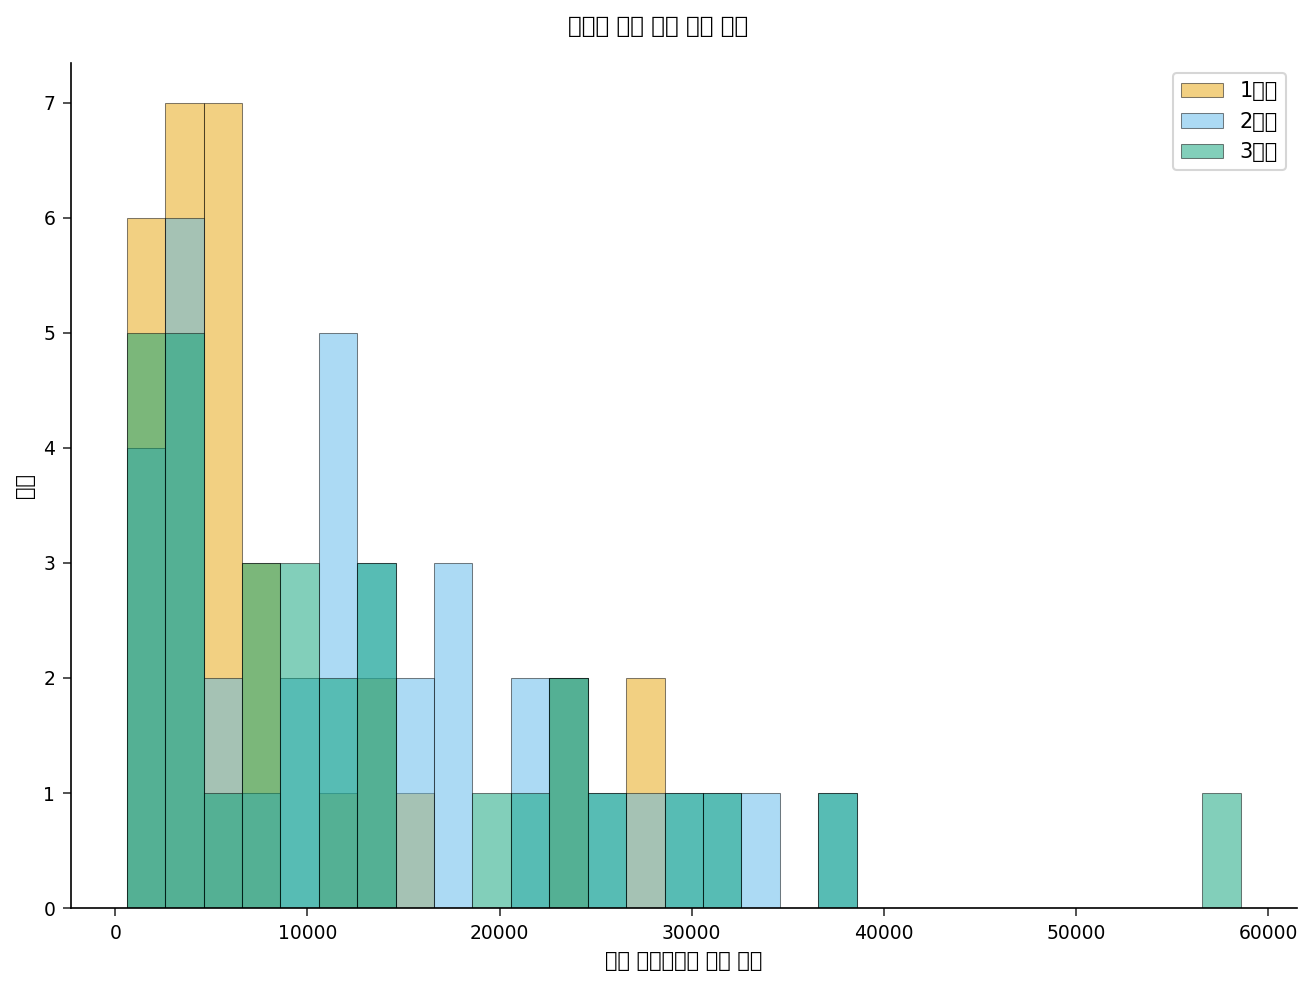

In [3]:
/* --------------------------------------------------------
   세대별 가동 시간 분포
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS 라벨="사건 발생까지의 가동 시간";
    YAXIS 라벨="빈도";
    제목 "세대별 설비 가동 시간 분포";
실행;


---


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

   Stratum: 세대 = 1세대   

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065     0.


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/cce4bb4c-3557-4c93-91fd-20e1cbe28941/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


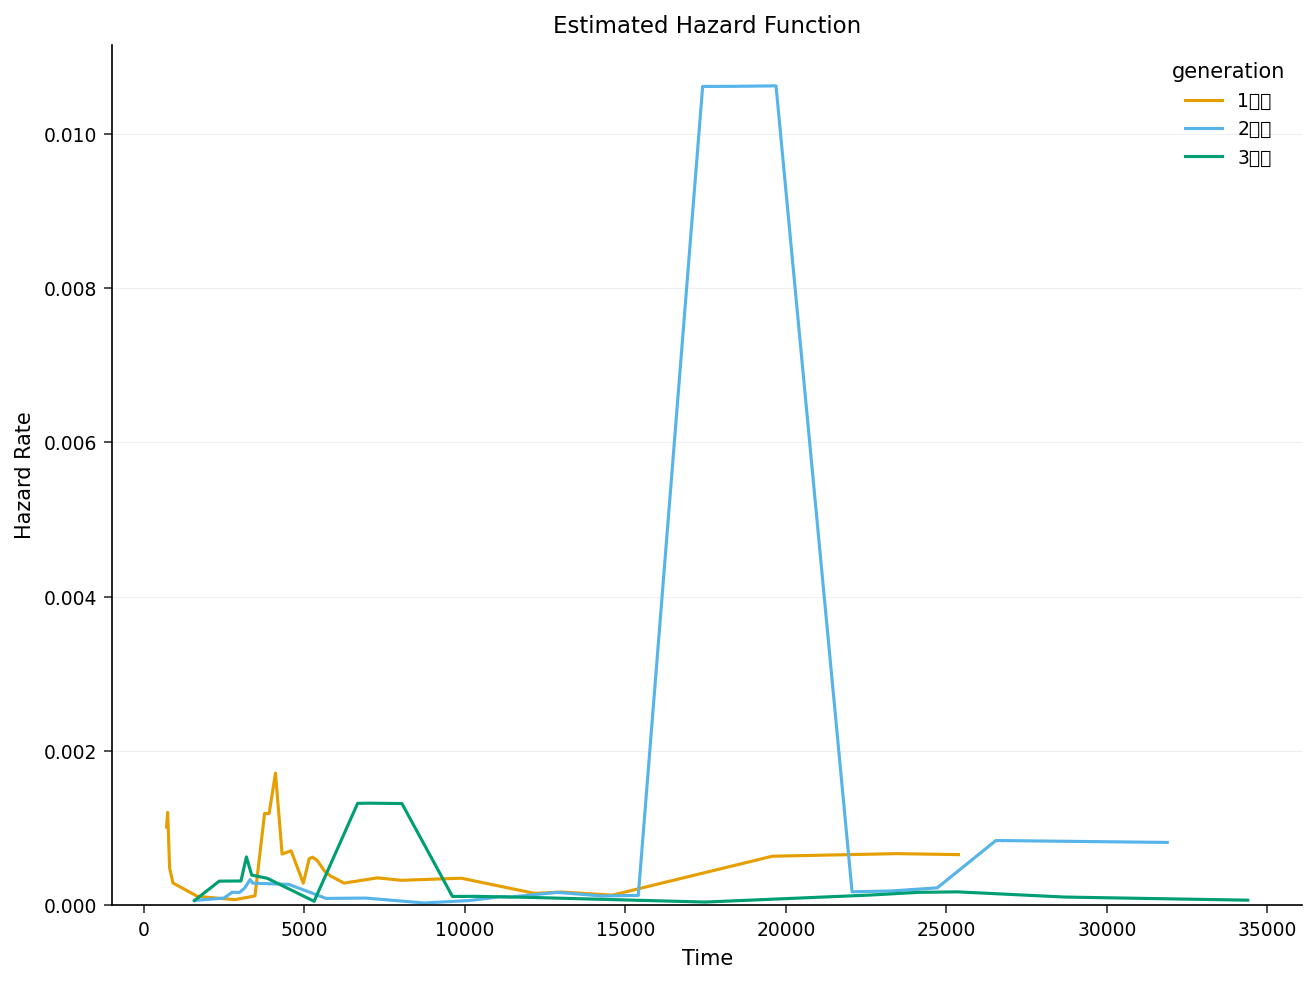

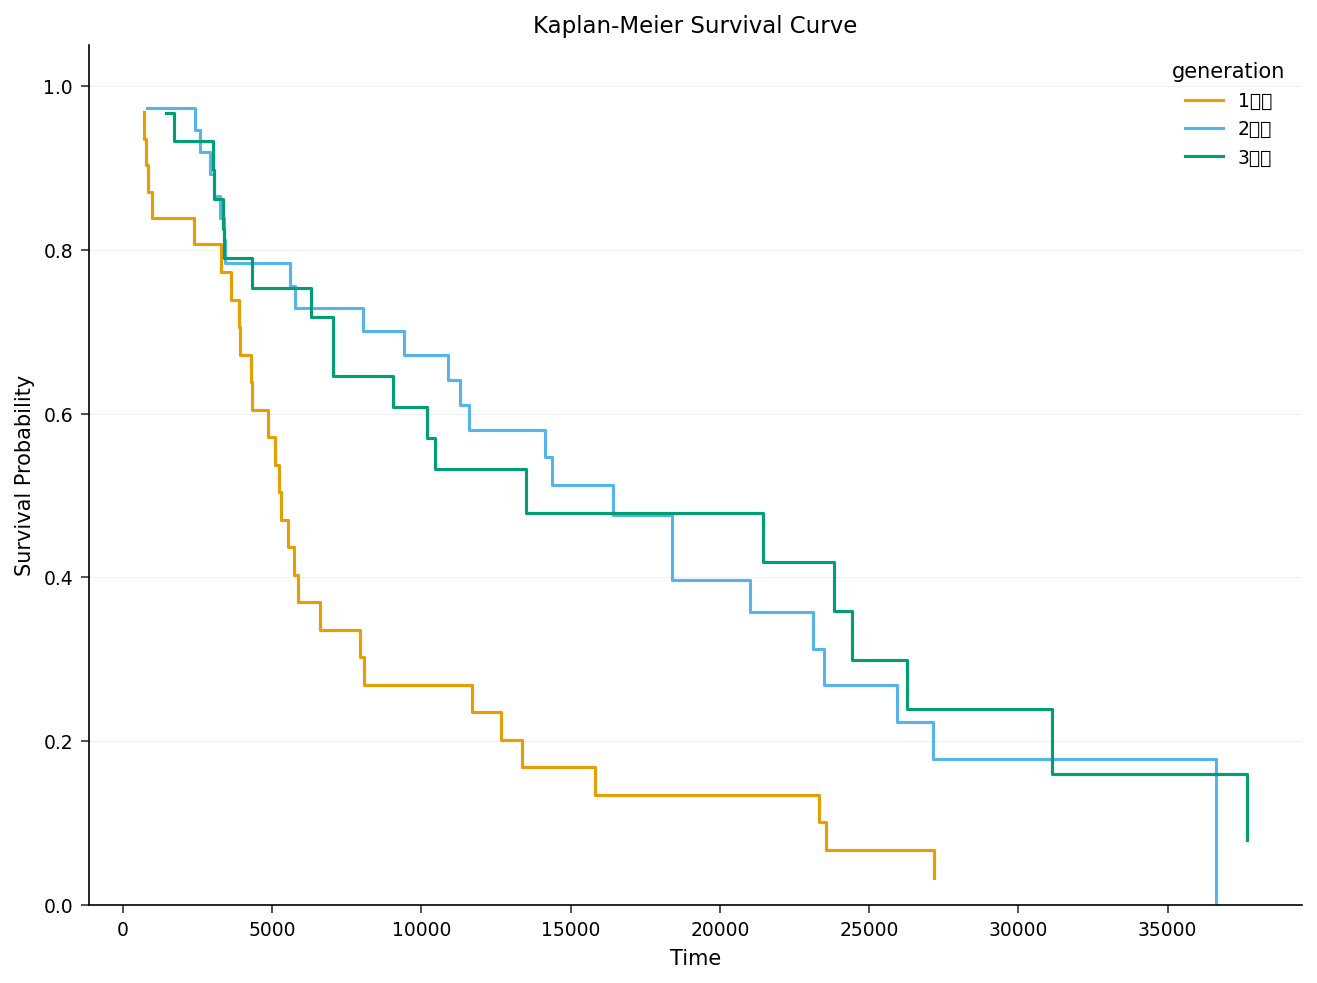

In [4]:
/* --------------------------------------------------------
   세대별 카플란-마이어 생존 추정. 위험함수 뷰를 위한
   넬슨-알렌 누적 위험 옵션을 함께 사용한다.

   STRATA generation / TEST=(LOGRANK WILCOXON)은 전체 가동 수명에
   걸친 차이에 민감한 로그순위(log-rank) 검정과, 초기 고장에 더
   큰 가중치를 주는 게한-브레슬로우-윌콕슨(Gehan-Breslow-Wilcoxon)
   검정을 세 세대에 대해 모두 수행한다.

   PLOTS=(SURVIVAL HAZARD)는 카플란-마이어 생존곡선과 커널
   평활화된 위험함수를 그린다.
   -------------------------------------------------------- */
처리 LIFETEST 데이터=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
    라벨 generation     = "세대"
          operating_hours = "가동 시간"
          failure_event   = "고장 여부";
실행;


In [5]:
/* --------------------------------------------------------
   세대별로 카플란-마이어 ODS 테이블에서 읽어온 가동 시간
   마일스톤(5,000 / 10,000 / 20,000 / 30,000시간)별 생존확률.
   -------------------------------------------------------- */
ODS 출력 productlimitestimates=work.equip_km_detail;

처리 LIFETEST 데이터=work.equipment_life METHOD=km;
    TIME operating_hours * failure_event(0);
    STRATA generation;
실행;

ODS 출력 CLOSE;

/* ProductLimitEstimates 테이블은 세대별로 서로 다른 시간마다
   한 행씩을 담고 있다. 각 마일스톤에 대해 해당 시점 이상인
   첫 번째 행 -- 즉 그 가동 시간에서 유효한 생존 추정값 --
   을 남긴다. */
처리 정렬 데이터=work.equip_km_detail;
    기준 generation operating_hours;
실행;

데이터 work.equip_milestones;
    설정 work.equip_km_detail;
    기준 generation;
    보존 hit5 hit10 hit20 hit30;
    만약 first.generation 이면 반복;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    종료;
    길이 milestone 8;
    milestone = .;
    만약      operating_hours >= 5000  그리고 hit5  = 0 이면 반복; milestone = 5000;  hit5  = 1; 종료;
    아니면 만약 operating_hours >= 10000 그리고 hit10 = 0 이면 반복; milestone = 10000; hit10 = 1; 종료;
    아니면 만약 operating_hours >= 20000 그리고 hit20 = 0 이면 반복; milestone = 20000; hit20 = 1; 종료;
    아니면 만약 operating_hours >= 30000 그리고 hit30 = 0 이면 반복; milestone = 30000; hit30 = 1; 종료;
    만약 milestone ne .;
    유지 generation milestone operating_hours SURVIVAL sdf_stderr;
실행;

처리 인쇄 데이터=work.equip_milestones noobs 라벨;
    라벨 generation     = "세대"
          milestone       = "마일스톤(시간)"
          operating_hours = "추정 시점"
          SURVIVAL        = "생존 확률"
          sdf_stderr      = "표준오차";
    형식 SURVIVAL sdf_stderr 6.4;
    제목 "세대별 가동 시간 마일스톤에서의 생존 확률";
실행;


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

 Stratum: generation = 1세대 

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065   


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---


### 해석

카플란-마이어 생존곡선은 전체 설비군을 뚜렷한 두 계층으로 나눈다.
원조 **1세대** 기계가 가장 빨리 고장난다. 이 곡선은 **가동 시간
5,282시간**(중앙 사용수명)에서 0.5 아래로 떨어지며, 10,000시간
시점에는 약 **24%**만이 여전히 가동 중이다. 재설계된 **2세대**와
**3세대** 기계는 훨씬 오래 생존한다 -- 중앙 수명이 각각 **16,430**,
**13,512**시간이며 -- 관측 구간 전체에서 두 생존곡선은 서로 가까이
붙어 있다. 5,000 / 10,000 / 20,000시간 마일스톤에서 추정 생존확률은
다음과 같다.

| 세대 | 5,000시간 | 10,000시간 | 20,000시간 |
|------------|--------:|---------:|---------:|
| 1세대 | 0.54 | 0.24 | 0.10 |
| 2세대 | 0.76 | 0.64 | 0.36 |
| 3세대 | 0.72 | 0.57 | 0.42 |

두 계층 동일성 검정 모두 세 세대가 하나의 생존분포를 공유한다는
귀무가설을 기각한다. **로그순위(log-rank)** 검정은 카이제곱
**12.92**(자유도 2, *p* = **0.0016**), **게한-브레슬로우-윌콕슨
(Gehan-Breslow-Wilcoxon)** 검정은 카이제곱 **11.88**(자유도 2,
*p* = **0.0026**)을 준다. 두 검정 결과가 서로 잘 일치하므로, 이
차이는 초기 고장 구간(윌콕슨 검정이 더 큰 가중치를 주는 부분)만이
아니라 사용수명 전반에 걸쳐 나타난다.

이는 세대를 거듭할수록 단조롭게 개선되는 것이 아니라 **단발성**
개선으로 읽어야 한다. 2세대와 3세대는 이 표본에서 통계적으로
구분되지 않는다 -- 두 곡선은 겹치고 2세대의 중앙값이 명목상 더
높다 -- 따라서 이 100대 표본에서는 3세대가 2세대보다 개선되었다는
증거가 없다. 실제 신호는 원조 1세대 설계와 이후 두 설계 사이의
크고 유의한 격차다.

넬슨-알렌 누적 위험 옵션은 함께 제공되는 위험함수 그래프를
만든다. 이 표본 크기에서는 커널 평활화된 위험함수가 다소
불안정하다 -- 18,000시간 부근의 뾰족한 2세대 스파이크는 실제
마모 고장 급증이 아니라, 위험집합이 작게 남은 상태에서 발생한
단일 사건을 반영한 것이다 -- 따라서 위험함수 뷰는 정성적으로만
참고해야 하며, 정량적 결론은 생존곡선과 정식 검정에 근거한다.

**권장사항.** 나머지 1세대 기계의 신뢰성이 나머지 설비군보다
현저히 떨어지므로, 교체와 더 엄격한 점검을 우선해야 한다. 2세대와
3세대는 둘 사이의 차이를 더 큰 표본으로 확인할 수 있을 때까지
정비 계획상 하나의 더 신뢰할 수 있는 코호트로 취급한다.

---


In [6]:
/* --------------------------------------------------------
   후속 신뢰성 대시보드를 위해 누적 위험/생존곡선 데이터와
   마일스톤 생존 테이블을 내보낸다.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>